In [1]:
# ============================================================
# 0) Imports + paths (usa tus NIfTI ya registrados en espacio 3T)
# ============================================================

import ants
import numpy as np
import matplotlib.pyplot as plt

# Ajusta estos paths a tus outputs ya registrados:
MAG_PATH = "../data/registered_7T_in_3T/001_20240313/mag_7T_in_3T.nii.gz"
PHX_PATH = "../data/registered_7T_in_3T/001_20240313/phaseX_7T_in_3T.nii.gz"
PHY_PATH = "../data/registered_7T_in_3T/001_20240313/phaseY_7T_in_3T.nii.gz"
PHZ_PATH = "../data/registered_7T_in_3T/001_20240313/phaseZ_7T_in_3T.nii.gz"


VENC = 0.90  # unidades: lo que sea que represente en tu dataset (normalmente m/s)

In [2]:
# ============================================================
# 1) Cargar 4D: magnitud + 3 fases (raw phase) en espacio 3T
# ============================================================

mag4d = ants.image_read(MAG_PATH, dimension=4, reorient=False)
phx4d = ants.image_read(PHX_PATH, dimension=4, reorient=False)
phy4d = ants.image_read(PHY_PATH, dimension=4, reorient=False)
phz4d = ants.image_read(PHZ_PATH, dimension=4, reorient=False)

print("MAG:", mag4d.shape, mag4d.spacing)
print("PHX:", phx4d.shape, phx4d.spacing)
print("PHY:", phy4d.shape, phy4d.spacing)
print("PHZ:", phz4d.shape, phz4d.spacing)

T = mag4d.shape[3]
assert phx4d.shape[3] == T and phy4d.shape[3] == T and phz4d.shape[3] == T

MAG: (448, 448, 48, 14) (0.5, 0.5, 0.5, 1.0)
PHX: (448, 448, 48, 14) (0.5, 0.5, 0.5, 1.0)
PHY: (448, 448, 48, 14) (0.5, 0.5, 0.5, 1.0)
PHZ: (448, 448, 48, 14) (0.5, 0.5, 0.5, 1.0)


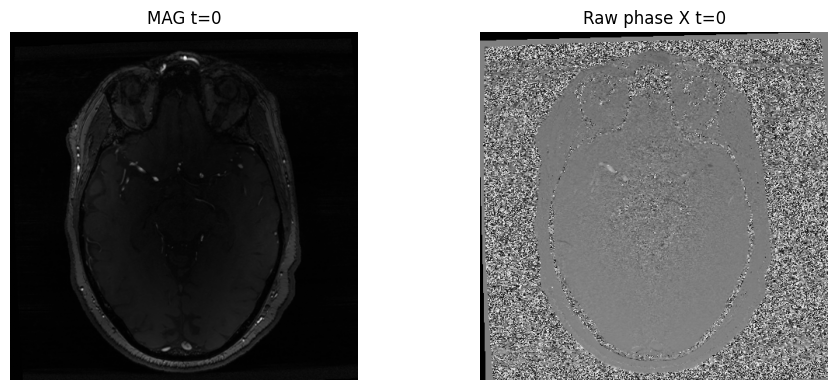

In [3]:
# ============================================================
# 2) Helper: extraer frame 3D (manteniendo metadata)
# ============================================================

def frame3d_from_4d(img4d, t):
    arr = img4d.numpy()[..., t]
    return ants.from_numpy(
        arr,
        spacing=img4d.spacing[:3],
        origin=img4d.origin[:3],
        direction=img4d.direction[:3,:3]
    )

# Quick look (mid-slice) en t=0
t0 = 0
mag0 = frame3d_from_4d(mag4d, t0)
phx0 = frame3d_from_4d(phx4d, t0)

z = mag0.shape[2]//2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mag0.numpy()[:,:,z].T, cmap="gray", origin="lower"); plt.title("MAG t=0"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(phx0.numpy()[:,:,z].T, cmap="gray", origin="lower"); plt.title("Raw phase X t=0"); plt.axis("off")
plt.tight_layout(); plt.show()

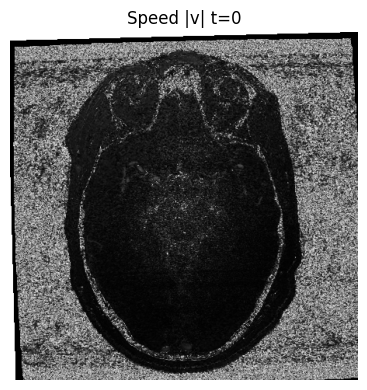

Speed t=0: min/mean/max = 0.0 0.6361226439476013 1.5588456392288208


In [7]:
# ============================================================
# 3) Convertir raw phase -> velocidad
# ============================================================


def phase_to_velocity(phase_img3d, venc):
    r = phase_img3d.numpy().astype(np.float32)
    v = (r-2048.0) * (venc / 2048.0)
    return ants.from_numpy(v, spacing=phase_img3d.spacing, origin=phase_img3d.origin, direction=phase_img3d.direction)

vx0 = phase_to_velocity(phx0, VENC)
vy0 = phase_to_velocity(frame3d_from_4d(phy4d, t0), VENC)
vz0 = phase_to_velocity(frame3d_from_4d(phz4d, t0), VENC)

speed0 = ants.from_numpy(
    np.sqrt(vx0.numpy()**2 + vy0.numpy()**2 + vz0.numpy()**2).astype(np.float32),
    spacing=mag0.spacing, origin=mag0.origin, direction=mag0.direction
)

# Visual speed
plt.figure(figsize=(5,4))
plt.imshow(speed0.numpy()[:,:,z].T, cmap="gray", origin="lower")
plt.title("Speed |v| t=0")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Speed t=0: min/mean/max =", float(speed0.min()), float(speed0.mean()), float(speed0.max()))

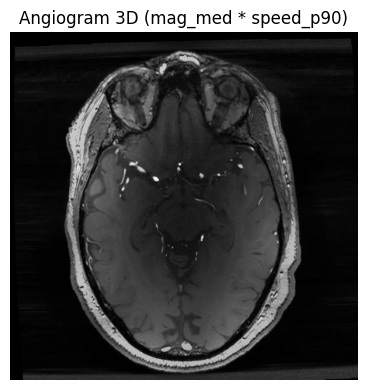

In [9]:
# ============================================================
# 4) Construir una “angiografía” 3D para segmentar vasos (PC-MRA-like)
# ============================================================
# Objetivo: resaltar vasos para segmentación del CoW.
# Estrategia simple y efectiva:
#   - speed(t) = sqrt(vx^2+vy^2+vz^2)
#   - speed_agg = percentil alto temporal (p.ej. 90) para enfatizar picos
#   - mag_agg   = mediana temporal (estable)
#   - angiogram = normalize(mag_agg) * normalize(speed_agg)
#
# Nota: esto no es una definición única de PC-MRA, pero funciona bien como "vessel-enhanced volume".

mag_np = mag4d.numpy().astype(np.float32)
phx_np = phx4d.numpy().astype(np.float32)
phy_np = phy4d.numpy().astype(np.float32)
phz_np = phz4d.numpy().astype(np.float32)

# velocity arrays
vx_np = (phx_np / np.pi) * VENC
vy_np = (phy_np / np.pi) * VENC
vz_np = (phz_np / np.pi) * VENC

speed_np = np.sqrt(vx_np**2 + vy_np**2 + vz_np**2).astype(np.float32)  # (x,y,z,T)

mag_med   = np.median(mag_np, axis=3).astype(np.float32)
speed_p90 = np.percentile(speed_np, 90, axis=3).astype(np.float32)

def robust_norm(vol, p_lo=1, p_hi=99):
    vals = vol[np.isfinite(vol)]
    lo, hi = np.percentile(vals, [p_lo, p_hi])
    if hi <= lo:
        return np.zeros_like(vol, dtype=np.float32)
    v = np.clip(vol, lo, hi)
    return ((v - lo) / (hi - lo)).astype(np.float32)

mag_n   = robust_norm(mag_med)
speed_n = robust_norm(speed_p90)

angi_np = (mag_n * speed_n).astype(np.float32)

angi3d = ants.from_numpy(
    angi_np,
    spacing=mag4d.spacing[:3],
    origin=mag4d.origin[:3],
    direction=mag4d.direction[:3,:3]
)

# Visual mid-slice angiogram
z = angi3d.shape[2]//2
plt.figure(figsize=(5,4))
plt.imshow(angi3d.numpy()[:,:,z].T, cmap="gray", origin="lower")
plt.title("Angiogram 3D (mag_med * speed_p90)")
plt.axis("off")
plt.tight_layout()
plt.show()

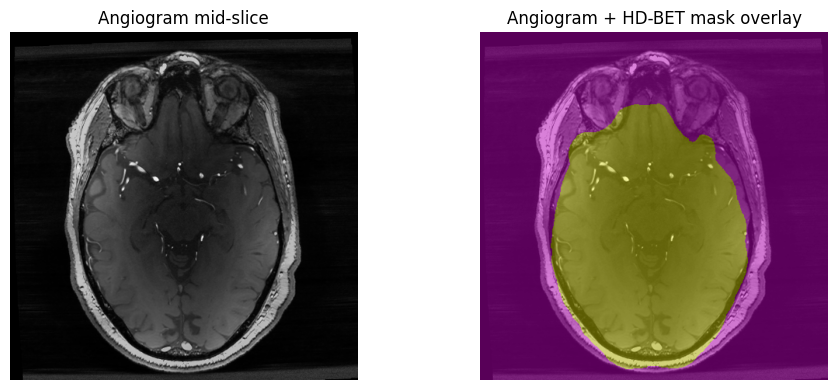

In [14]:
HD_BET_MASK_PATH = "../data/registered_7T_in_3T/001_20240313/QC/hdbet_moving_7t/brain_mask_bet.nii.gz"  # ajusta
brain_mask_hdbet = ants.image_read(HD_BET_MASK_PATH)

# Asegura misma grilla que angi3d (interp nearest)
brain_mask = ants.resample_image_to_target(brain_mask_hdbet, angi3d, interp_type=0)
brain_mask = ants.threshold_image(brain_mask, 0.5, 1e9)  # binaria
brain_mask = ants.iMath(brain_mask, "FillHoles")
brain_mask = ants.iMath(brain_mask, "GetLargestComponent")

# Visual overlay angiogram + mask


z = angi3d.shape[2]//2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(angi3d.numpy()[:,:,z].T, cmap="gray", origin="lower")
plt.title("Angiogram mid-slice")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(angi3d.numpy()[:,:,z].T, cmap="gray", origin="lower")
plt.imshow(brain_mask.numpy()[:,:,z].T, cmap="spring", origin="lower", alpha=0.35)
plt.title("Angiogram + HD-BET mask overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

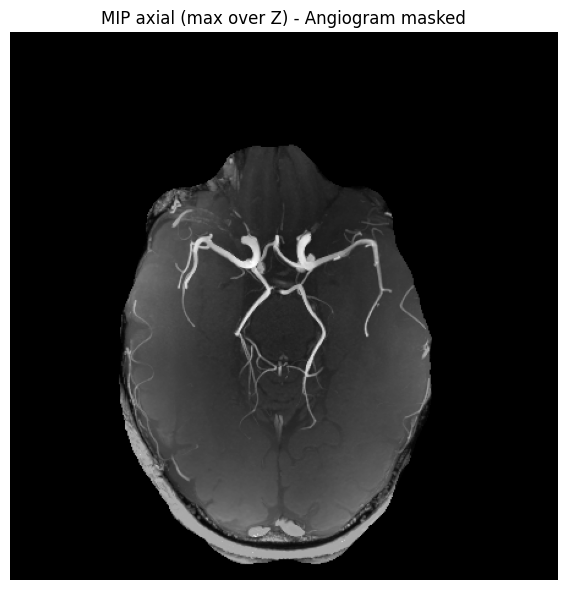

In [15]:
# ============================================================
# 6) MIP (solo para localizar CoW / QC, NO como segmentación final)
# ============================================================
# Hacemos MIP en Z (axial) del angiogram dentro del brain mask.

angi_masked = angi3d.numpy() * (brain_mask.numpy() > 0)

mip_z = np.max(angi_masked, axis=2)  # (x,y)

plt.figure(figsize=(6,6))
plt.imshow(mip_z.T, cmap="gray", origin="lower")
plt.title("MIP axial (max over Z) - Angiogram masked")
plt.axis("off")
plt.tight_layout()
plt.show()

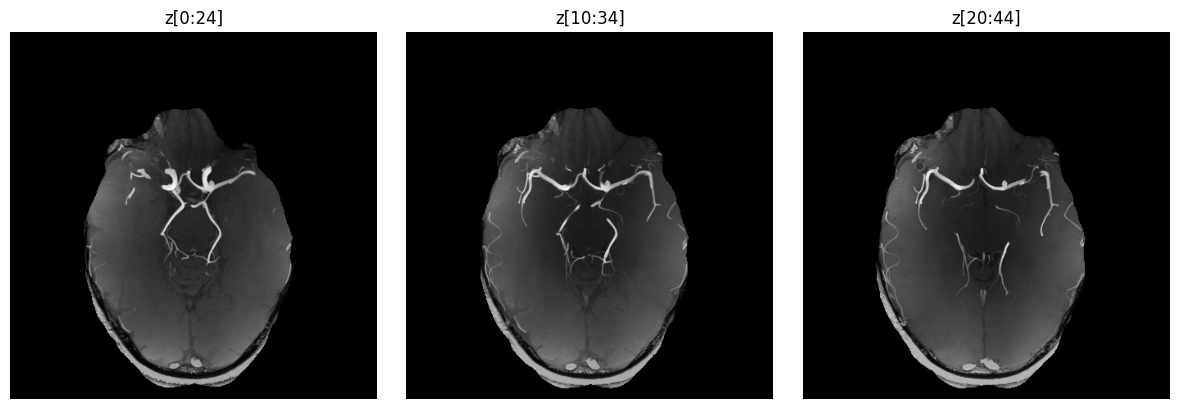

In [18]:
angi_np = angi3d.numpy().astype(np.float32)
mask_np = (brain_mask.numpy() > 0)

angi_m = angi_np * mask_np
Z = angi_m.shape[2]

win = 24   # tamaño ventana en slices (prueba 20–40)
step = 10  # salto (prueba 8–16)

mips, zs = [], []
for z0 in range(0, Z - win + 1, step):
    z1 = z0 + win
    mips.append(np.max(angi_m[:, :, z0:z1], axis=2))
    zs.append((z0, z1))

cols = 4
rows = int(np.ceil(len(mips)/cols))
plt.figure(figsize=(4*cols, 4*rows))
for i, mip in enumerate(mips):
    plt.subplot(rows, cols, i+1)
    plt.imshow(mip.T, cmap="gray", origin="lower")
    plt.title(f"z[{zs[i][0]}:{zs[i][1]}]")
    plt.axis("off")
plt.tight_layout()
plt.show()

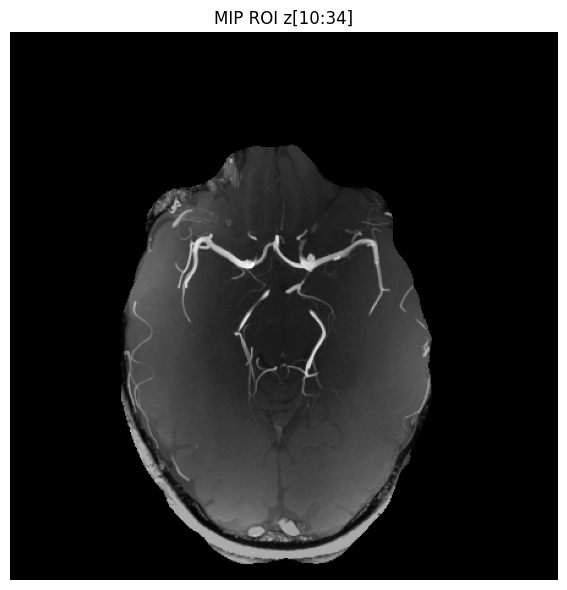

In [19]:
z_min, z_max = 10, 34  # <- reemplaza con los tuyos

angi_roi = angi_m[:, :, z_min:z_max]
mask_roi = mask_np[:, :, z_min:z_max]

plt.figure(figsize=(6,6))
plt.imshow(np.max(angi_roi, axis=2).T, cmap="gray", origin="lower")
plt.title(f"MIP ROI z[{z_min}:{z_max}]")
plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import ants

angi_roi_img = ants.from_numpy(
    angi_roi.astype(np.float32),
    spacing=angi3d.spacing,
    origin=angi3d.origin,
    direction=angi3d.direction
)

# Suavizado leve
angi_sm = ants.smooth_image(angi_roi_img, 1.0)

vals = angi_sm.numpy()[mask_roi]
thr = float(np.percentile(vals, 99.3))  # prueba 99.0–99.7

seg = (angi_sm.numpy() >= thr) & mask_roi
seg_img = ants.from_numpy(seg.astype(np.uint8), spacing=angi3d.spacing, origin=angi3d.origin, direction=angi3d.direction)

# Limpieza morfológica
seg_img = ants.iMath(seg_img, "MD", 1)
seg_img = ants.iMath(seg_img, "ME", 1)
seg_img = ants.iMath(seg_img, "FillHoles")
seg_img = ants.iMath(seg_img, "GetLargestComponent")

# QC MIP de la segmentación
plt.figure(figsize=(6,6))
plt.imshow(np.max(seg_img.numpy(), axis=2).T, cmap="gray", origin="lower")
plt.title(f"Seg MIP (thr p99.3={thr:.4g})")
plt.axis("off")
plt.tight_layout()
plt.show()

: 